# **Homework 1 - Alex Chen**

**Section 2.4.9**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
auto = pd.read_csv('Auto.csv')
auto.head()

**a.**

In [96]:
quant = auto.select_dtypes(include=[np.number]).columns
qual = auto.select_dtypes(exclude=[np.number]).columns

print("Quantitative predictors:", list(quant))
print("Qualitative predictors:", list(qual))

# Quantitative predictors: mpg, cylinders, displacement, weight, acceleration, year, origin
# Qualitative predictors: horsepower, name

# When prompted with “How to separate the variables in the auto DataFrame into quantitative and qualitative predictors?”
# the ChatGPT-generated text indicated that select_dtypes(include=[np.number]) selects only numeric columns
# and .columns extracts the column names (OpenAI, 2026).

Quantitative predictors: ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'year', 'origin']
Qualitative predictors: ['horsepower', 'name']


**b.**

In [73]:
ranges = auto[quant].agg(['min', 'max'])
ranges

,mpg,cylinders,displacement,weight,acceleration,year,origin
min,9.0,3,68.0,1613,8.0,70,1
max,46.6,8,455.0,5140,24.8,82,3


**c.**

In [74]:
stats = auto[quant].agg(['mean', 'std'])
stats

,mpg,cylinders,displacement,weight,acceleration,year,origin
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549


**d.**

In [75]:
sub = auto.drop(auto.index[9:85])

sub_ranges = sub[quant].agg(['min', 'max'])
sub_stats = sub[quant].agg(['mean', 'std'])

sub_ranges, sub_stats

(      mpg  cylinders  displacement  weight  acceleration  year  origin
 min  11.0          3          68.0    1649           8.5    70       1
 max  46.6          8         455.0    4997          24.8    82       3,
             mpg  cylinders  displacement       weight  acceleration  \
 mean  24.438629   5.370717    187.049844  2933.962617     15.723053   
 std    7.908184   1.653486     99.635385   810.642938      2.680514   
 
            year    origin  
 mean  77.152648  1.598131  
 std    3.111230  0.816163  )

**e.**

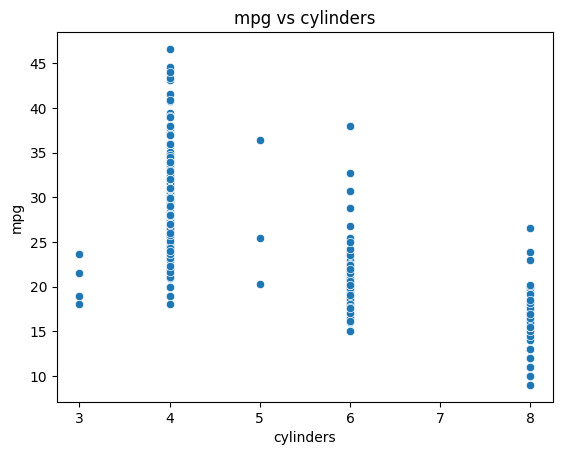

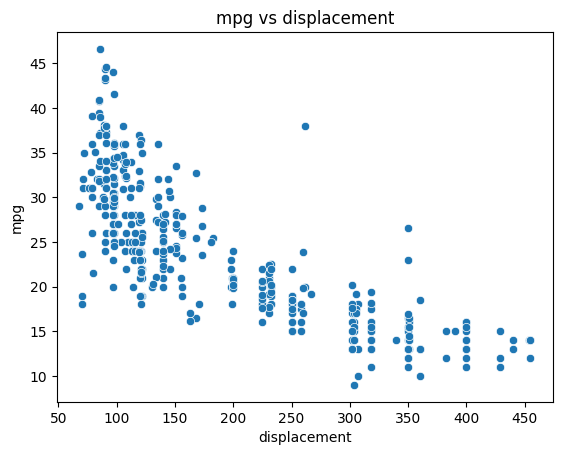

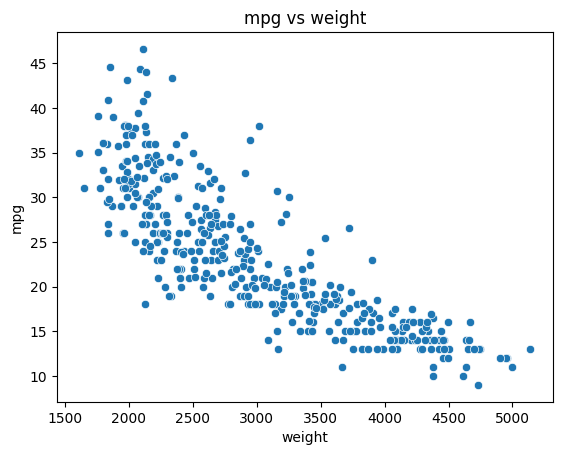

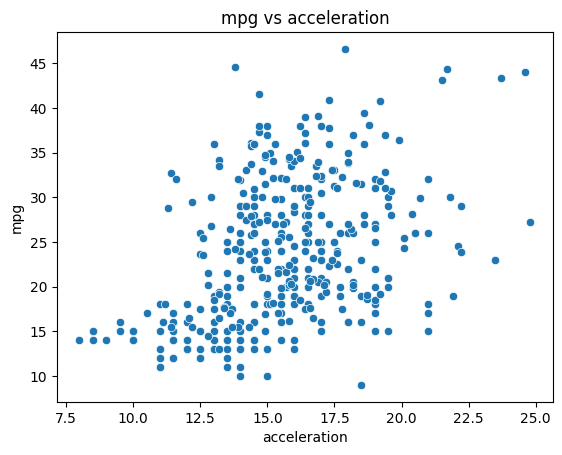

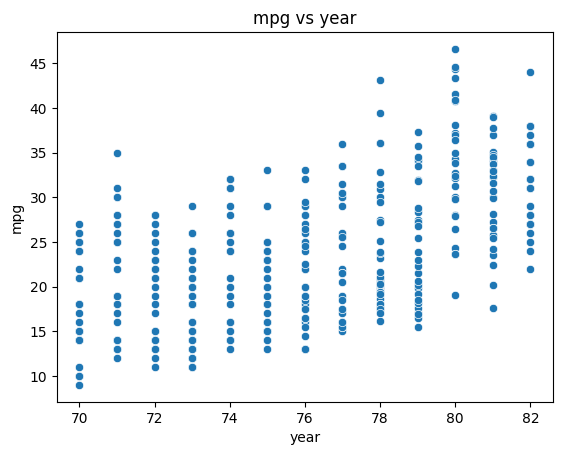

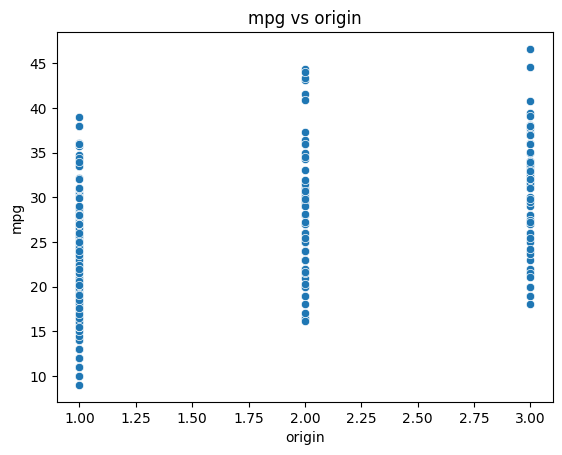

In [92]:
for col in quant:
    if col != 'mpg':
        plt.figure()
        sns.scatterplot(x=auto[col], y=auto['mpg'])
        plt.xlabel(col)
        plt.ylabel('mpg')
        plt.title(f'mpg vs {col}')
        plt.show()

**f.**

In [77]:
auto[quant].corr()['mpg'].sort_values(ascending=False)

mpg             1.000000
year            0.581469
origin          0.563698
acceleration    0.422297
cylinders      -0.776260
displacement   -0.804443
weight         -0.831739
Name: mpg, dtype: float64

Weight has a strong negative relationship with mpg, −0.83, which means that heavier cars usually get worse gas mileage. Displacement, −0.80, also show strong negative relationships with mpg, meaning that larger engines reduce fuel efficiency. The strongest factors of mpg are weight, displacement, cylinder, and year. These relationships are also consistent with the patterns in the scatter-plots, where you an see mpg decreases as engine size and vehicle weight increase, and increases for newer model years.

**Section 2.4.2**

**a.**

Regression. Inference. $n = 500$. $p = 3$.

**b.**

Classification. Prediction. $n = 20$. $p = 13$.

**c.**

Regression. Prediction. $n = 52$. $p = 3$.

**Section 2.4.4**

**a.**

1. Email Spam Detection:

Response: Spam or Not Spam

Predictors: Email words, sender address, number of links, subject line

Goal: Prediction. Want to classify new emails correctly, not wonder why an email is spam

2. Medical Diagnosis:

Response: Cancer or No Cancer

Predictors: Age, blood test results, tumor size, symptoms

Goal: Prediction. Want to classify the disease early and accurately identity patients.

3. Loan Approval:

Response: Approved or Denied

Predictors: Credit score, income, employment history, debt history

Goal: Inference: Understand which factors most affect loan repayment.

**b.**

1. Predicting House Prices:

Response: House Price

Predictors: Number of bedrooms, location, size, age of home, neighborhood quality

Goal: Prediction. Main goal is to estimate the price of a house accurately

2. Forecasting Weather Temperature:

Response: Temperature

Predictors: Humidity, wind speed, pressure, historical weather

Goal: Prediction. Main goal is to predict future temperature values

3. Estimating Test Scores:

Response: Test Score

Predictors: Hours studied, attendance, previous grades

Goal: Inference. Goal is to understand which factors affect the performance of the test takers.

**Section 2.4.3**

**a.**

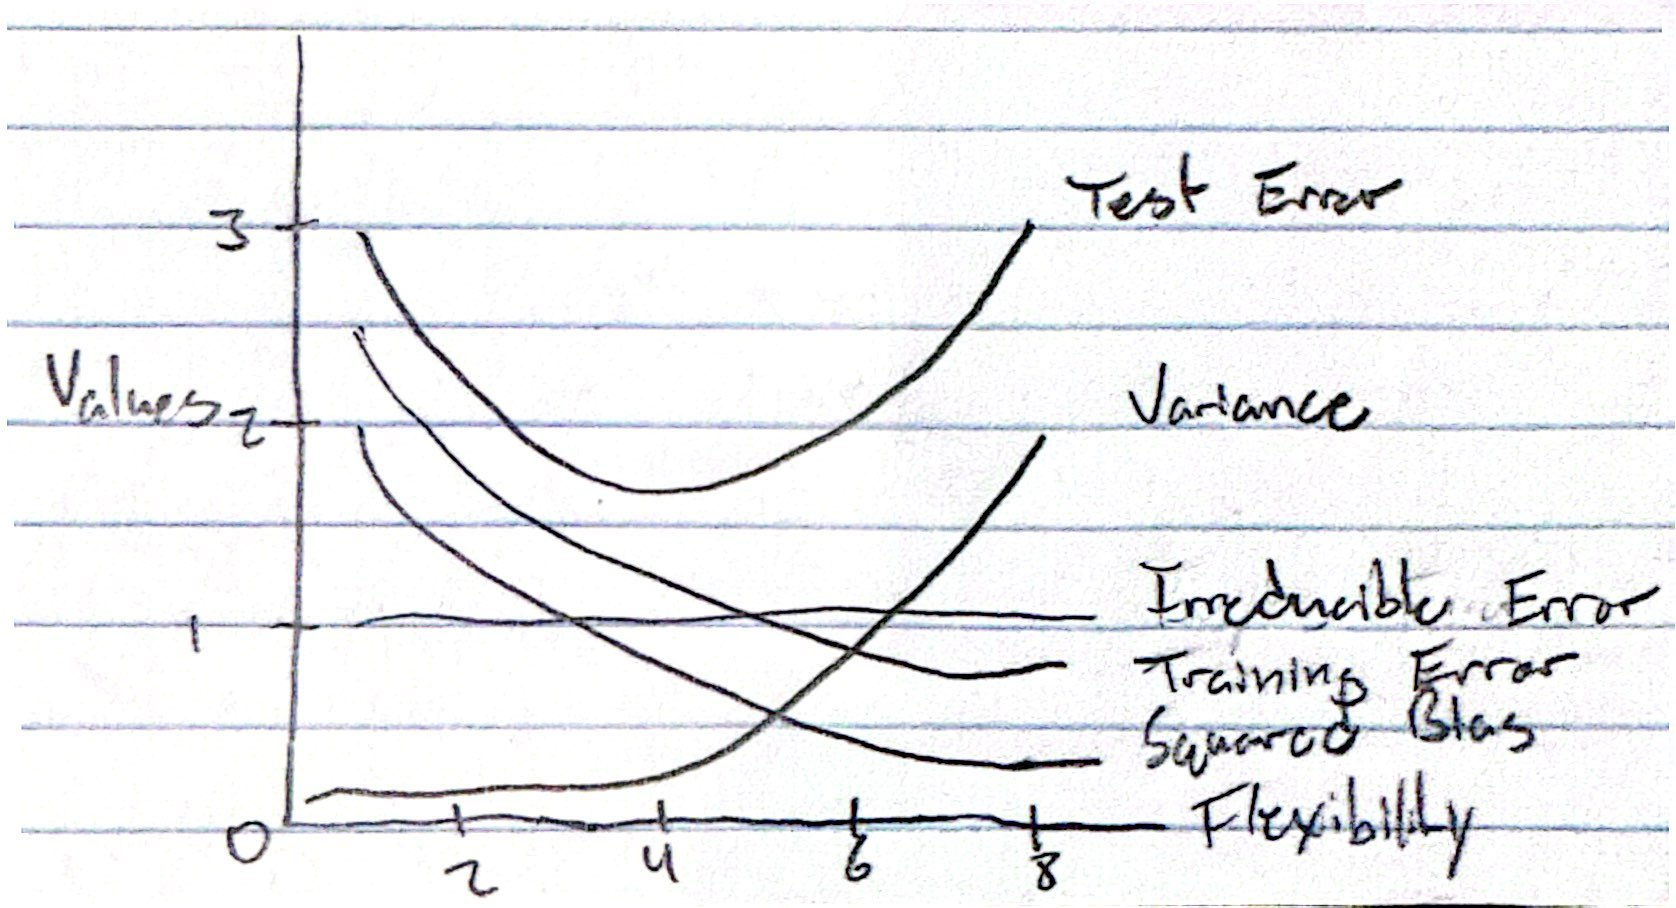

**b.**

Squared bias: Bias is the error that comes from using a model that is too simple to match the true relationship. A more flexible model can fit the true pattern better, so the bias gets smaller as flexibility increases.
In some cases, bias can even reach zero

Variance: Variance measures how much the model changes when we use different training data. If the model has no flexibility, it will always produce the same result no matter what data we use, so the variance is zero. As the model becomes more flexible, the variance increases.

Training error: Training error is how well the model fits the data it was trained on. A simple model usually has a high training error because it cannot fit the data well. As the model becomes more flexible, the training error decreases.

Test error. Test error is the error on new data haven’t seen before. It adds bias, variance, and irreducible error. At first, increasing flexibility reduces bias and improves test error. But after it keeps going, the model becomes too flexible and starts overfitting, so variance increases and test error rises again. Test error forms a U shape.

Irreducible error. Irreducible error is the lowest possible error possible because it comes from random noise in the data. It stays constant.

**Section 2.4.3**

**a.**

In [48]:
import pandas as pd
college = pd.read_csv("College.csv", index_col=0)

**b.**

In [49]:
college

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


**c.**

In [50]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


**d.**

array([[<Axes: xlabel='Top10perc', ylabel='Top10perc'>,
        <Axes: xlabel='Apps', ylabel='Top10perc'>,
        <Axes: xlabel='Enroll', ylabel='Top10perc'>],
       [<Axes: xlabel='Top10perc', ylabel='Apps'>,
        <Axes: xlabel='Apps', ylabel='Apps'>,
        <Axes: xlabel='Enroll', ylabel='Apps'>],
       [<Axes: xlabel='Top10perc', ylabel='Enroll'>,
        <Axes: xlabel='Apps', ylabel='Enroll'>,
        <Axes: xlabel='Enroll', ylabel='Enroll'>]], dtype=object)

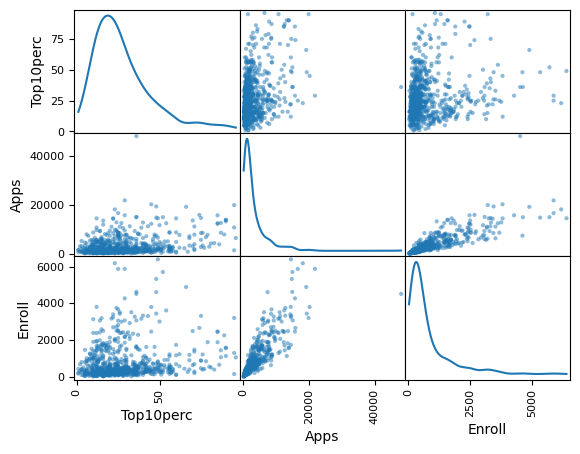

In [84]:
from pandas.plotting import scatter_matrix

scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']], diagonal='kde')

# Had to search how to code so that the diagonal graphs were line graphs, and had to code diagonal='kde' at the end

**e.**

<Axes: title={'center': 'Outstate'}, xlabel='Private'>

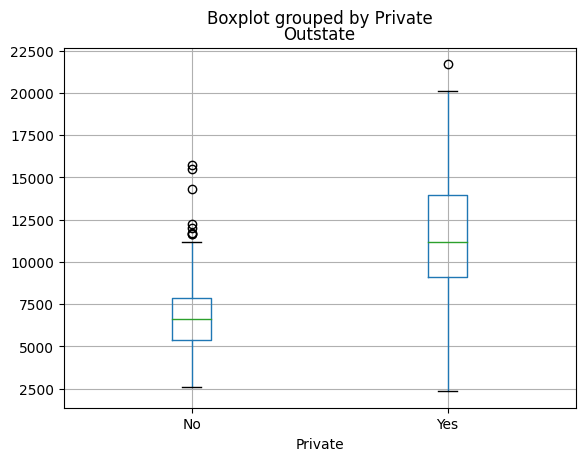

In [55]:
college.boxplot(column='Outstate', by='Private')

**f.**

Elite
No     699
Yes     78
Name: count, dtype: int64


<Axes: title={'center': 'Outstate'}, xlabel='Elite'>

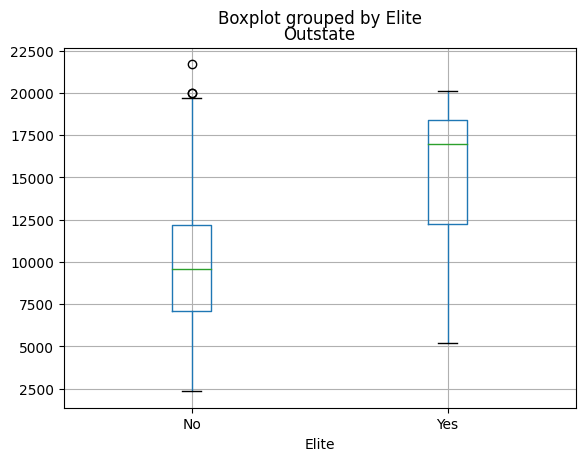

In [94]:
college['Elite'] = pd.cut(college['Top10perc'], bins=[0, 50, 100], labels=['No', 'Yes'])
print(college['Elite'].value_counts())
college.boxplot(column='Outstate', by='Elite')

**g.**

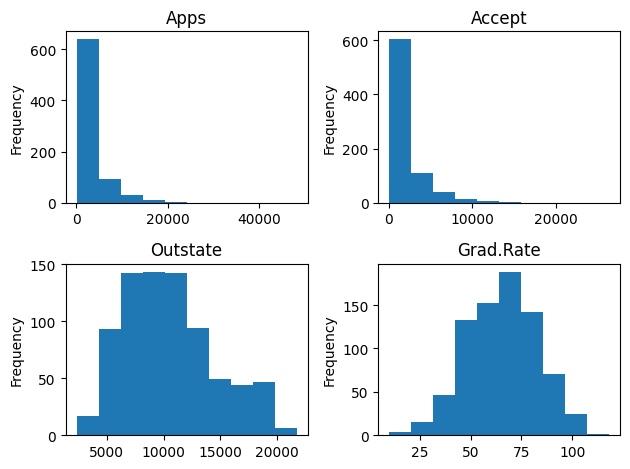

In [90]:
fig, axes = plt.subplots(2, 2)

college['Apps'].plot.hist(ax=axes[0, 0])
axes[0, 0].set_title('Apps')

college['Accept'].plot.hist(ax=axes[0, 1])
axes[0, 1].set_title('Accept')

college['Outstate'].plot.hist(ax=axes[1, 0])
axes[1, 0].set_title('Outstate')

college['Grad.Rate'].plot.hist(ax=axes[1, 1])
axes[1, 1].set_title('Grad.Rate')

plt.tight_layout()
plt.show()

**h.**

<class 'pandas.core.frame.DataFrame'>
Index: 777 entries, Abilene Christian University to York College of Pennsylvania
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      777 non-null    object  
 1   Apps         777 non-null    int64   
 2   Accept       777 non-null    int64   
 3   Enroll       777 non-null    int64   
 4   Top10perc    777 non-null    int64   
 5   Top25perc    777 non-null    int64   
 6   F.Undergrad  777 non-null    int64   
 7   P.Undergrad  777 non-null    int64   
 8   Outstate     777 non-null    int64   
 9   Room.Board   777 non-null    int64   
 10  Books        777 non-null    int64   
 11  Personal     777 non-null    int64   
 12  PhD          777 non-null    int64   
 13  Terminal     777 non-null    int64   
 14  S.F.Ratio    777 non-null    float64 
 15  perc.alumni  777 non-null    int64   
 16  Expend       777 non-null    int64   
 17  Grad.Rate    777 non-null 

<Axes: title={'center': 'Outstate'}, xlabel='Private'>

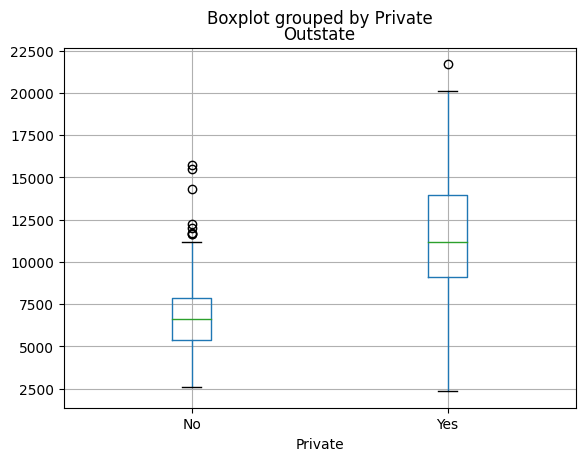

In [60]:
college.info()
college.describe()
college['Elite'].value_counts()
college.boxplot(column='Outstate', by='Private')

Summary: There are 777 colleges. Several columns are numeric. Private and Elite are categorical. Most colleges have around 3,000 applications. Average out-of-state tuition is around 9,000–10,000 dollars. Graduation rate averages around 65%. Only a small number of colleges have more than 50% students from top 10%. Most colleges are not elite by using this ranking. Private schools usually have higher out-of-state tuition. Public schools have more variability, but lower median tuition.